# 숙제 3

데이터과학 입문

원중호 (서울대학교 통계학과)  
June 2026

## 지시사항

제출마감 2026-06-15 23:00

1.  R과 Python을 모두 사용하여 사용된 코드와 데이터랭글링 절차,
    분석결과를 설명한다. 두 언어의 분석결과가 차이가 있으면 그 이유를
    설명한다.
2.  [Quarto
    Markdown](https://quarto.org/docs/authoring/markdown-basics.html)을
    사용한다. 제공된 숙제 `.qmd` 파일에 본인의 답안을 “답안” 절에
    추가하여 제출한다. Quarto Markdown은 RStudio 또는 Visual Studio
    Code에 [Quarto
    Extension](https://marketplace.visualstudio.com/items?itemName=quarto.quarto)을
    추가하여 컴파일, 다른 문서 형식으로 변환할 수 있다.
3.  R의 `reticulate` 패키지를 사용하면 하나의 `.qmd` 파일 안에서 R과
    Python을 동시에 사용할 수 있다. 이때 다음 문법을 사용하여 두 언어
    코드를 탭으로 구분한다. 숙제 `.qmd` 파일은 `reticulate`을 사용하도록
    준비되어 있다.

```` markdown
::: {.panel-tabset}

## R

```{r}
R code
```

## Python

```{python}
Python code
```

:::
````

1.  `.qmd`를 컴파일하여 생성된 `.html` 파일을 함께 저장소에 제출한다.
2.  함께 제공된 `student.yml`을 함께 작성하여 저장소에 제출한다.

## 평가 기준

1.  재현성: 제출된 저장소의 `.qmd` 파일을 컴파일하여 함께 제출된 `.html`
    파일과 동일한 결과가 나와야 한다.
2.  분석의 정확성: 분석은 올바른 기술적 세부 사항을 포함하여 수행되어야
    한다.
3.  보고서의 전반적인 품질: 데이터 가공 및 분석 결과가 명확하고 자세하게
    설명되어야 한다.
4.  코드의 전반적인 품질: 코드는 체계적으로 정리되어 있어야 하며,
    가독성을 높이기 위해 적절한 주석이 포함되어야 한다.

#### **늦게 제출된 과제물은 받지 않는다.**

# 1부 교과서 연습문제

## 문제 1-1

1.  MDSR 10장 연습문제 10.6.6

### 답안

## R

``` r
# 10.6.6.
library(tidyverse)
library(NHANES)
library(ggplot2)
library(broom)
library(dplyr)
library(forcats)

# 20대 이상의 성인 중 흡연자 여부 판정, 결측치는 비흡연자로 분류 
smoke_dat <- NHANES %>%
  dplyr::filter(Age >= 20) %>%
  dplyr::mutate(
    CurrentSmoke = dplyr::case_when(
      Smoke100 == "No" ~ 0,
      Smoke100 == "Yes" & SmokeNow == "Yes" ~ 1,
      Smoke100 == "Yes" & SmokeNow == "No" ~ 0,
      TRUE ~ NA_real_
    ),
    CurrentSmoke = factor(CurrentSmoke, levels = c(0, 1),
                          labels = c("No", "Yes"))
  )

# 설명변수 선택 및 결측 제거 & 로지스틱 적합 
# 우선 설명변수는 흡연과 이론적으로 관련 있는 변수들을 후보로 두되 결측치가 많은 변수는 포함하지 않는다 
model_dat <- smoke_dat %>%
  dplyr::select(
    CurrentSmoke,
    Age,
    Gender,
    Race1,
    Education,
    MaritalStatus,
    Poverty,
    BMI,
    Diabetes,
    HealthGen,
    PhysActive,
    AlcoholDay
  ) %>%
  tidyr::drop_na()

fit <- glm(
  CurrentSmoke ~ Age + Gender + Race1 + Education + MaritalStatus +
    Poverty + BMI + Diabetes + HealthGen + PhysActive + AlcoholDay,
  data = model_dat,
  family = binomial
)

summary(fit)
```


    Call:
    glm(formula = CurrentSmoke ~ Age + Gender + Race1 + Education + 
        MaritalStatus + Poverty + BMI + Diabetes + HealthGen + PhysActive + 
        AlcoholDay, family = binomial, data = model_dat)

    Coefficients:
                               Estimate Std. Error z value Pr(>|z|)    
    (Intercept)                1.338033   0.408485   3.276 0.001054 ** 
    Age                       -0.012036   0.003352  -3.591 0.000330 ***
    Gendermale                 0.049793   0.087356   0.570 0.568675    
    Race1Hispanic             -0.803337   0.212720  -3.777 0.000159 ***
    Race1Mexican              -1.497847   0.207705  -7.211 5.54e-13 ***
    Race1White                -0.127257   0.130163  -0.978 0.328236    
    Race1Other                 0.223651   0.198291   1.128 0.259366    
    Education9 - 11th Grade   -0.012018   0.225132  -0.053 0.957426    
    EducationHigh School      -0.428023   0.220798  -1.939 0.052559 .  
    EducationSome College     -0.641125   0.220340  -2.910 0.003618 ** 
    EducationCollege Grad     -1.429530   0.239170  -5.977 2.27e-09 ***
    MaritalStatusLivePartner   0.343399   0.169677   2.024 0.042986 *  
    MaritalStatusMarried      -0.750918   0.132798  -5.655 1.56e-08 ***
    MaritalStatusNeverMarried -0.545548   0.153882  -3.545 0.000392 ***
    MaritalStatusSeparated    -0.261120   0.272077  -0.960 0.337193    
    MaritalStatusWidowed      -0.667276   0.252543  -2.642 0.008236 ** 
    Poverty                   -0.097969   0.029173  -3.358 0.000784 ***
    BMI                       -0.050254   0.006958  -7.223 5.10e-13 ***
    DiabetesYes               -0.681219   0.175163  -3.889 0.000101 ***
    HealthGenVgood             0.530188   0.177377   2.989 0.002798 ** 
    HealthGenGood              0.938395   0.174358   5.382 7.37e-08 ***
    HealthGenFair              1.431767   0.197945   7.233 4.72e-13 ***
    HealthGenPoor              1.011661   0.341051   2.966 0.003014 ** 
    PhysActiveYes             -0.514587   0.088475  -5.816 6.02e-09 ***
    AlcoholDay                 0.154663   0.016741   9.238  < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 4720.7  on 4507  degrees of freedom
    Residual deviance: 3799.1  on 4483  degrees of freedom
    AIC: 3849.1

    Number of Fisher Scoring iterations: 5

``` r
# AIC 기준 stepwise 변수선택
# 충돌방지를 위해 library(MASS) -> MASS:stepAIC
fit_step <- MASS::stepAIC(
  fit,
  direction = "both",
  trace = TRUE
)
```

    Start:  AIC=3849.14
    CurrentSmoke ~ Age + Gender + Race1 + Education + MaritalStatus + 
        Poverty + BMI + Diabetes + HealthGen + PhysActive + AlcoholDay

                    Df Deviance    AIC
    - Gender         1   3799.5 3847.5
    <none>               3799.1 3849.1
    - Poverty        1   3810.4 3858.4
    - Age            1   3812.2 3860.2
    - Diabetes       1   3815.7 3863.7
    - PhysActive     1   3833.1 3881.1
    - BMI            1   3855.3 3903.3
    - HealthGen      4   3871.5 3913.5
    - MaritalStatus  5   3882.2 3922.2
    - Race1          4   3885.4 3927.4
    - Education      4   3893.6 3935.6
    - AlcoholDay     1   3899.2 3947.2

    Step:  AIC=3847.47
    CurrentSmoke ~ Age + Race1 + Education + MaritalStatus + Poverty + 
        BMI + Diabetes + HealthGen + PhysActive + AlcoholDay

                    Df Deviance    AIC
    <none>               3799.5 3847.5
    + Gender         1   3799.1 3849.1
    - Poverty        1   3810.6 3856.6
    - Age            1   3812.3 3858.3
    - Diabetes       1   3815.7 3861.7
    - PhysActive     1   3833.1 3879.1
    - BMI            1   3855.5 3901.5
    - HealthGen      4   3871.9 3911.9
    - MaritalStatus  5   3882.3 3920.3
    - Race1          4   3885.5 3925.5
    - Education      4   3894.8 3934.8
    - AlcoholDay     1   3908.8 3954.8

``` r
summary(fit_step)
```


    Call:
    glm(formula = CurrentSmoke ~ Age + Race1 + Education + MaritalStatus + 
        Poverty + BMI + Diabetes + HealthGen + PhysActive + AlcoholDay, 
        family = binomial, data = model_dat)

    Coefficients:
                               Estimate Std. Error z value Pr(>|z|)    
    (Intercept)                1.345209   0.408244   3.295 0.000984 ***
    Age                       -0.011876   0.003340  -3.556 0.000376 ***
    Race1Hispanic             -0.802858   0.212753  -3.774 0.000161 ***
    Race1Mexican              -1.492518   0.207475  -7.194 6.30e-13 ***
    Race1White                -0.124924   0.130097  -0.960 0.336934    
    Race1Other                 0.229141   0.198128   1.157 0.247464    
    Education9 - 11th Grade   -0.015607   0.224969  -0.069 0.944690    
    EducationHigh School      -0.432355   0.220562  -1.960 0.049967 *  
    EducationSome College     -0.646384   0.220052  -2.937 0.003310 ** 
    EducationCollege Grad     -1.436938   0.238736  -6.019 1.76e-09 ***
    MaritalStatusLivePartner   0.347876   0.169513   2.052 0.040149 *  
    MaritalStatusMarried      -0.746039   0.132486  -5.631 1.79e-08 ***
    MaritalStatusNeverMarried -0.540288   0.153598  -3.518 0.000436 ***
    MaritalStatusSeparated    -0.261681   0.272132  -0.962 0.336253    
    MaritalStatusWidowed      -0.679224   0.251461  -2.701 0.006911 ** 
    Poverty                   -0.097515   0.029170  -3.343 0.000829 ***
    BMI                       -0.050143   0.006946  -7.219 5.23e-13 ***
    DiabetesYes               -0.674053   0.174647  -3.860 0.000114 ***
    HealthGenVgood             0.527247   0.177269   2.974 0.002937 ** 
    HealthGenGood              0.936983   0.174324   5.375 7.66e-08 ***
    HealthGenFair              1.430629   0.197935   7.228 4.91e-13 ***
    HealthGenPoor              1.002779   0.340638   2.944 0.003242 ** 
    PhysActiveYes             -0.511691   0.088330  -5.793 6.92e-09 ***
    AlcoholDay                 0.157181   0.016188   9.710  < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 4720.7  on 4507  degrees of freedom
    Residual deviance: 3799.5  on 4484  degrees of freedom
    AIC: 3847.5

    Number of Fisher Scoring iterations: 5

``` r
# 오즈비로 시각화 
or_plot_dat <- broom::tidy(fit_step, exponentiate = TRUE, conf.int = TRUE) %>%
  dplyr::filter(term != "(Intercept)") %>%
  dplyr::mutate(
    term = forcats::fct_reorder(term, estimate)
  )

ggplot(or_plot_dat,
       aes(x = estimate, y = term)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "gray50") +
  geom_point(size = 2.5, color = "#2C7FB8") +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high),
                 height = 0.2, color = "#2C7FB8") +
  scale_x_log10() +
  labs(
    title = "Predictors of Current Smoking",
    x = "Odds Ratio, log scale",
    y = "Predictor"
  ) +
  theme_minimal()
```

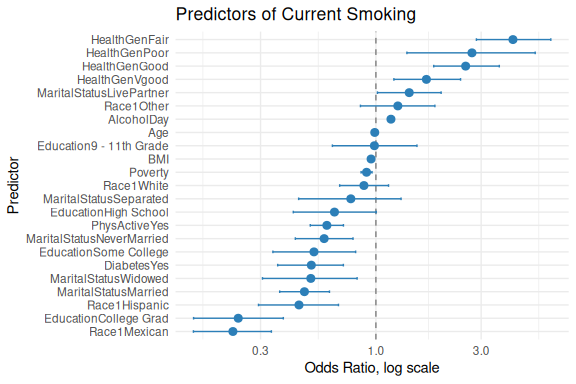

## Python

``` python
# 10.6.6.
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

nhanes = pd.read_csv("NHANES.csv")

# 전처리 
if "rownames" in nhanes.columns:
    nhanes = nhanes.drop(columns=["rownames"])

# 20대 이상의 성인 중 흡연자 여부 판정, 결측치는 비흡연자로 분류 
smoke_dat = nhanes[nhanes["Age"] >= 20].copy()

smoke_dat["CurrentSmoke"] = np.select(
    [
        smoke_dat["Smoke100"] == "No",
        (smoke_dat["Smoke100"] == "Yes") & (smoke_dat["SmokeNow"] == "Yes"),
        (smoke_dat["Smoke100"] == "Yes") & (smoke_dat["SmokeNow"] == "No")
    ],
    [
        0,
        1,
        0
    ],
    default=np.nan
)

# 설명변수 선택 및 결측 제거
vars_used = [
    "CurrentSmoke",
    "Age",
    "Gender",
    "Race1",
    "Education",
    "MaritalStatus",
    "Poverty",
    "BMI",
    "Diabetes",
    "HealthGen",
    "PhysActive",
    "AlcoholDay"
]

model_dat = smoke_dat[vars_used].dropna().copy()

# 로지스틱 회귀 적합
full_formula = """
CurrentSmoke ~ Age + C(Gender) + C(Race1) + C(Education) + C(MaritalStatus)
+ Poverty + BMI + C(Diabetes) + C(HealthGen) + C(PhysActive) + AlcoholDay
"""

fit = smf.glm(
    formula=full_formula,
    data=model_dat,
    family=sm.families.Binomial()
).fit()

print(fit.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:           CurrentSmoke   No. Observations:                 4508
    Model:                            GLM   Df Residuals:                     4483
    Model Family:                Binomial   Df Model:                           24
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1899.6
    Date:                Sun, 14 Jun 2026   Deviance:                       3799.1
    Time:                        05:31:54   Pearson chi2:                 4.50e+03
    No. Iterations:                     6   Pseudo R-squ. (CS):             0.1849
    Covariance Type:            nonrobust                                         
    ====================================================================================================
                                           coef    std err          z      P>|z|      [0.025      0.975]
    ----------------------------------------------------------------------------------------------------
    Intercept                            1.3380      0.408      3.276      0.001       0.537       2.139
    C(Gender)[T.male]                    0.0498      0.087      0.570      0.569      -0.121       0.221
    C(Race1)[T.Hispanic]                -0.8033      0.213     -3.776      0.000      -1.220      -0.386
    C(Race1)[T.Mexican]                 -1.4978      0.208     -7.211      0.000      -1.905      -1.091
    C(Race1)[T.Other]                    0.2237      0.198      1.128      0.259      -0.165       0.612
    C(Race1)[T.White]                   -0.1273      0.130     -0.978      0.328      -0.382       0.128
    C(Education)[T.9 - 11th Grade]      -0.0120      0.225     -0.053      0.957      -0.453       0.429
    C(Education)[T.College Grad]        -1.4295      0.239     -5.977      0.000      -1.898      -0.961
    C(Education)[T.High School]         -0.4280      0.221     -1.939      0.053      -0.861       0.005
    C(Education)[T.Some College]        -0.6411      0.220     -2.910      0.004      -1.073      -0.209
    C(MaritalStatus)[T.LivePartner]      0.3434      0.170      2.024      0.043       0.011       0.676
    C(MaritalStatus)[T.Married]         -0.7509      0.133     -5.655      0.000      -1.011      -0.491
    C(MaritalStatus)[T.NeverMarried]    -0.5455      0.154     -3.545      0.000      -0.847      -0.244
    C(MaritalStatus)[T.Separated]       -0.2611      0.272     -0.960      0.337      -0.794       0.272
    C(MaritalStatus)[T.Widowed]         -0.6673      0.253     -2.642      0.008      -1.162      -0.172
    C(Diabetes)[T.Yes]                  -0.6812      0.175     -3.889      0.000      -1.025      -0.338
    C(HealthGen)[T.Fair]                 1.4318      0.198      7.233      0.000       1.044       1.820
    C(HealthGen)[T.Good]                 0.9384      0.174      5.382      0.000       0.597       1.280
    C(HealthGen)[T.Poor]                 1.0117      0.341      2.966      0.003       0.343       1.680
    C(HealthGen)[T.Vgood]                0.5302      0.177      2.989      0.003       0.183       0.878
    C(PhysActive)[T.Yes]                -0.5146      0.088     -5.816      0.000      -0.688      -0.341
    Age                                 -0.0120      0.003     -3.591      0.000      -0.019      -0.005
    Poverty                             -0.0980      0.029     -3.358      0.001      -0.155      -0.041
    BMI                                 -0.0503      0.007     -7.223      0.000      -0.064      -0.037
    AlcoholDay                           0.1547      0.017      9.238      0.000       0.122       0.187
    ====================================================================================================

``` python
# AIC 기준 stepwise 변수선택, stepAIC가 없어 직접 구현
candidate_terms = [
    "Age",
    "C(Gender)",
    "C(Race1)",
    "C(Education)",
    "C(MaritalStatus)",
    "Poverty",
    "BMI",
    "C(Diabetes)",
    "C(HealthGen)",
    "C(PhysActive)",
    "AlcoholDay"
]

def make_formula(terms):
    return "CurrentSmoke ~ " + " + ".join(terms)

def fit_aic(terms, data):
    formula = make_formula(terms)
    model = smf.glm(
        formula=formula,
        data=data,
        family=sm.families.Binomial()
    ).fit()
    return model, model.aic

def stepwise_aic(data, terms, trace=True):
    current_terms = terms.copy()
    current_model, current_aic = fit_aic(current_terms, data)

    if trace:
        print("Start AIC:", current_aic)
        print(make_formula(current_terms))

    improved = True

    while improved:
        improved = False
        results = []

        # backward: 변수 하나 제거
        for term in current_terms:
            trial_terms = [t for t in current_terms if t != term]
            if len(trial_terms) == 0:
                continue

            try:
                trial_model, trial_aic = fit_aic(trial_terms, data)
                results.append((trial_aic, trial_terms, trial_model, f"Remove {term}"))
            except Exception:
                pass

        # forward: 제거된 변수 다시 추가
        for term in terms:
            if term not in current_terms:
                trial_terms = current_terms + [term]

                try:
                    trial_model, trial_aic = fit_aic(trial_terms, data)
                    results.append((trial_aic, trial_terms, trial_model, f"Add {term}"))
                except Exception:
                    pass

        if len(results) == 0:
            break

        best_aic, best_terms, best_model, action = min(results, key=lambda x: x[0])

        if best_aic < current_aic:
            current_aic = best_aic
            current_terms = best_terms
            current_model = best_model
            improved = True

            if trace:
                print(action)
                print("AIC:", current_aic)
                print(make_formula(current_terms))

    return current_model, current_terms

fit_step, selected_terms = stepwise_aic(model_dat, candidate_terms, trace=True)
```

    Start AIC: 3849.1424574749735
    CurrentSmoke ~ Age + C(Gender) + C(Race1) + C(Education) + C(MaritalStatus) + Poverty + BMI + C(Diabetes) + C(HealthGen) + C(PhysActive) + AlcoholDay
    Remove C(Gender)
    AIC: 3847.467398713216
    CurrentSmoke ~ Age + C(Race1) + C(Education) + C(MaritalStatus) + Poverty + BMI + C(Diabetes) + C(HealthGen) + C(PhysActive) + AlcoholDay

``` python
print(fit_step.summary())
```

                     Generalized Linear Model Regression Results                  
    ==============================================================================
    Dep. Variable:           CurrentSmoke   No. Observations:                 4508
    Model:                            GLM   Df Residuals:                     4484
    Model Family:                Binomial   Df Model:                           23
    Link Function:                  Logit   Scale:                          1.0000
    Method:                          IRLS   Log-Likelihood:                -1899.7
    Date:                Sun, 14 Jun 2026   Deviance:                       3799.5
    Time:                        05:31:57   Pearson chi2:                 4.50e+03
    No. Iterations:                     6   Pseudo R-squ. (CS):             0.1848
    Covariance Type:            nonrobust                                         
    ====================================================================================================
                                           coef    std err          z      P>|z|      [0.025      0.975]
    ----------------------------------------------------------------------------------------------------
    Intercept                            1.3452      0.408      3.295      0.001       0.545       2.145
    C(Race1)[T.Hispanic]                -0.8029      0.213     -3.774      0.000      -1.220      -0.386
    C(Race1)[T.Mexican]                 -1.4925      0.207     -7.194      0.000      -1.899      -1.086
    C(Race1)[T.Other]                    0.2291      0.198      1.157      0.247      -0.159       0.617
    C(Race1)[T.White]                   -0.1249      0.130     -0.960      0.337      -0.380       0.130
    C(Education)[T.9 - 11th Grade]      -0.0156      0.225     -0.069      0.945      -0.457       0.425
    C(Education)[T.College Grad]        -1.4369      0.239     -6.019      0.000      -1.905      -0.969
    C(Education)[T.High School]         -0.4324      0.221     -1.960      0.050      -0.865   -6.15e-05
    C(Education)[T.Some College]        -0.6464      0.220     -2.937      0.003      -1.078      -0.215
    C(MaritalStatus)[T.LivePartner]      0.3479      0.170      2.052      0.040       0.016       0.680
    C(MaritalStatus)[T.Married]         -0.7460      0.132     -5.631      0.000      -1.006      -0.486
    C(MaritalStatus)[T.NeverMarried]    -0.5403      0.154     -3.518      0.000      -0.841      -0.239
    C(MaritalStatus)[T.Separated]       -0.2617      0.272     -0.962      0.336      -0.795       0.272
    C(MaritalStatus)[T.Widowed]         -0.6792      0.251     -2.701      0.007      -1.172      -0.186
    C(Diabetes)[T.Yes]                  -0.6741      0.175     -3.860      0.000      -1.016      -0.332
    C(HealthGen)[T.Fair]                 1.4306      0.198      7.228      0.000       1.043       1.819
    C(HealthGen)[T.Good]                 0.9370      0.174      5.375      0.000       0.595       1.279
    C(HealthGen)[T.Poor]                 1.0028      0.341      2.944      0.003       0.335       1.670
    C(HealthGen)[T.Vgood]                0.5272      0.177      2.974      0.003       0.180       0.875
    C(PhysActive)[T.Yes]                -0.5117      0.088     -5.793      0.000      -0.685      -0.339
    Age                                 -0.0119      0.003     -3.556      0.000      -0.018      -0.005
    Poverty                             -0.0975      0.029     -3.343      0.001      -0.155      -0.040
    BMI                                 -0.0501      0.007     -7.219      0.000      -0.064      -0.037
    AlcoholDay                           0.1572      0.016      9.710      0.000       0.125       0.189
    ====================================================================================================

``` python
print(selected_terms)
```

    ['Age', 'C(Race1)', 'C(Education)', 'C(MaritalStatus)', 'Poverty', 'BMI', 'C(Diabetes)', 'C(HealthGen)', 'C(PhysActive)', 'AlcoholDay']

``` python
# 6. Odds ratio table 만들기

params = fit_step.params
conf = fit_step.conf_int()
pvalues = fit_step.pvalues

or_table = pd.DataFrame({
    "term": params.index,
    "estimate": np.exp(params),
    "conf_low": np.exp(conf[0]),
    "conf_high": np.exp(conf[1]),
    "p_value": pvalues
})

or_table = or_table[or_table["term"] != "Intercept"].copy()

# term 이름 정리
def clean_term(term):
    term = term.replace("C(", "")
    term = term.replace(")[T.", "")
    term = term.replace("]", "")
    return term

or_table["term_clean"] = or_table["term"].apply(clean_term)

# 오즈비 기준 정렬
or_table = or_table.sort_values("estimate")

# 7. Odds ratio plot
plt.figure(figsize=(10, 8))

plt.errorbar(
    x=or_table["estimate"],
    y=or_table["term_clean"],
    xerr=[
        or_table["estimate"] - or_table["conf_low"],
        or_table["conf_high"] - or_table["estimate"]
    ],
    fmt="o",
    color="#2C7FB8",
    ecolor="#2C7FB8",
    capsize=3
)

plt.axvline(x=1, linestyle="--", color="gray")
plt.xscale("log")

plt.title("Predictors of Current Smoking", fontsize=16)
plt.xlabel("Odds Ratio, log scale")
plt.ylabel("Predictor")

plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
```

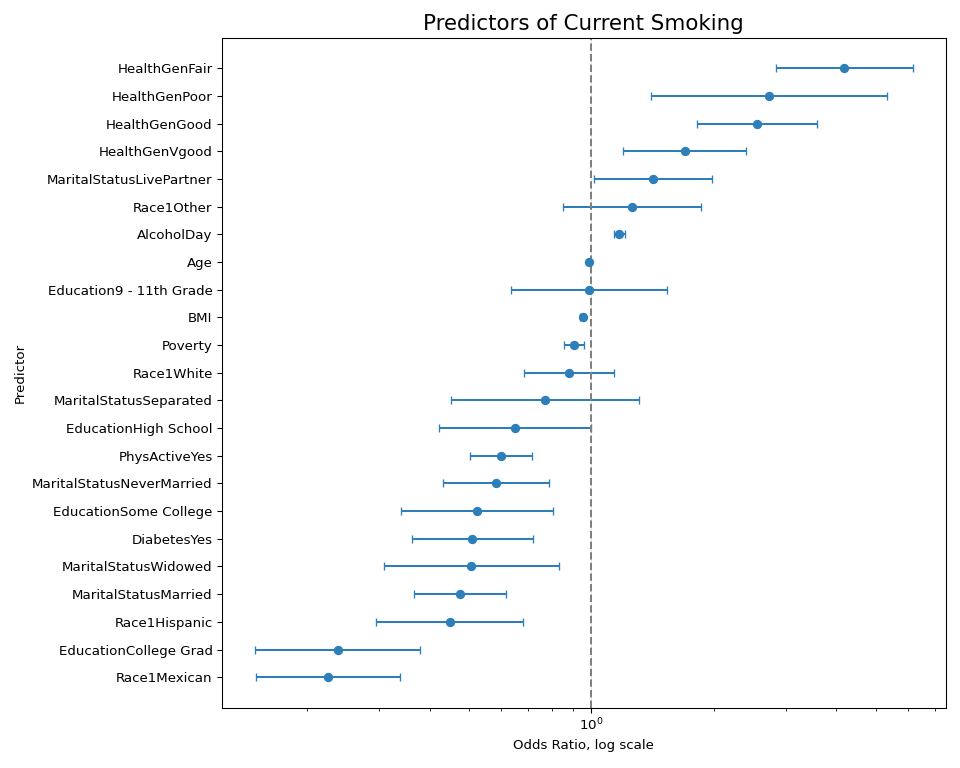

# 2부 데이터 분석 실무

### 분석 관련 공통 지침

1.  관측단위(observational unit)는 `playerID`와 `yearID`의 고유한
    조합으로 한다. 즉, 데이터프레임의 각 행은 한 선수의 특정 연도에
    해당해야 하고(예: 2019년 류현진), 한 선수의 특정 연도가 두 번 이상
    나타나서는 안 된다. 이적을 한 경우 원자료에서는 두 번 이상 나타날 수
    있으므로 주의해야 한다.
2.  데이터 분석을 하는 중에 필요한 경우 pivoting으로 각 행이 한명의
    선수에 해당하는 wide format data를 만들어서 연도간 비교를 하는 것은
    허용한다.

## 문제 2-1

Lahman Package의 `Teams` 데이터프레임에서 코로나 시즌인 2020년을 제외한
2010년부터 2025년 사이의 데이터를 이용하여 다음 질문에 답하라.

1.  MDSR Chapter 7 Iteration 에서 배운 Bill James의 공식을 변형한 다음
    모형을 데이터에 적합하고, 모수 $k$의 점추정치와 신뢰구간을 구하라.
    $$  WPct = \frac{RS^k}{S^k+RA^k} = \frac{1}{1+(RA/RS)^k}$$

2.  회귀계수 $\beta_1$이 위 모형의 $k$와 거의 같은 의미를 가지는
    로지스틱 회귀 모형을 세우고 이를 데이터에 적합하라. 모수와
    점추정치와 신뢰구간을 구하고 이를 1항의 결과와 비교하라.

    *주의*: 절편이 없는 모형을 적합해야 함. *힌트 1*. 로짓은
    $\log〖WPct/(1-WPct)$로 계산됨. *힌트 2*. 로짓의 역함수인 sigmoid는
    $\frac{1}{1+e^{-x}}$로 계산됨.

3.  2항의 모형 적합 결과에 대한 다음 세가지 진단 중 최소 두가지 이상을
    수행하여 모형적합이 잘 되었는지 확인하라.

    1.  Residual Deviance에 대한 해석 (카이제곱 분포와 비교)
    2.  Deviance residuals vs linear predictors ($\eta$) 산점도
    3.  관측된 WPct와 모형에서 예측하는 WPct를 산점도 그래프로 비교

4.  `WPct`를 반응변수로, `log(RA)`와 `log(RS)`를 설명변수로 하는 절편이
    없는 로지스틱선형회귀 모형을 적합하고 회귀계수들의 추정 결과를 a와
    b항의 결과와 비교하라. (유사한 모형을 얻는지 여부 등)

### 답안

## R

```` markdown
```{r}
# Problem 2-1
library(Lahman)
library(dplyr)
library(ggplot2)

# 데이터 전처리 : 팀-연도 데이터 생성 
teams_2_1 <- Lahman::Teams %>%
  filter(
    yearID >= 2010,
    yearID <= 2025,
    yearID != 2020,
    !is.na(W), !is.na(L), !is.na(R), !is.na(RA),
    W + L > 0,
    R > 0,
    RA > 0
  ) %>%
  transmute(
    yearID,
    franchID,
    teamID,
    W,
    L,
    G = W + L,
    RS = R,
    RA = RA,
    WPct = W / (W + L),
    log_ratio = log(R / RA),
    logRS = log(R),
    logRA = log(RA),
    logit_WPct = log(WPct / (1 - WPct))
  ) %>%
  filter(WPct > 0, WPct < 1)

# 1. Bill James 공식 
bj_nls <- nls(
  WPct ~ 1 / (1 + (RA / RS)^k),
  data = teams_2_1,
  start = list(k = 2),
  algorithm = "port",
  lower = c(k = 0)
)

k_hat <- coef(bj_nls)[["k"]]
print("k의 점추정량 ": k_hat)

k_ci <- tryCatch(
  confint(bj_nls)["k", ],
  error = function(e) {
    se <- summary(bj_nls)$parameters["k", "Std. Error"]
    df <- df.residual(bj_nls)
    c(
      `2.5 %` = k_hat - qt(0.975, df = df) * se,
      `97.5 %` = k_hat + qt(0.975, df = df) * se
    )
  }
)

print("95% 신뢰구간 ": k_ci)


# 2. 절편이 없는 로지스틱 회귀
glm_ratio <- glm(
  WPct ~ 0 + log_ratio,
  data = teams_2_1,
  weights = G,
  family = binomial(link = "logit")
)


beta1_hat <- coef(glm_ratio)[["log_ratio"]]
beta1_ci <- confint.default(glm_ratio)["log_ratio", ]

print("beta의 점추정량, 95% 신뢰구간 :")
print(beta1_hat)
print(beta1_ci)
print("1의 결과와 매우 유사")


# 3. 모형적합결과 진단 
teams_2_1 <- teams_2_1 %>%
  mutate(
    eta_ratio = predict(glm_ratio, type = "link"),
    pred_ratio = predict(glm_ratio, type = "response"),
    pred_ratio_manual = 1 / (1 + exp(-eta_ratio)),
    deviance_resid = residuals(glm_ratio, type = "deviance")
  )

# i. Residual deviance에 대한 해석 
resid_dev <- deviance(glm_ratio)
resid_df <- df.residual(glm_ratio)
resid_dev_p <- pchisq(resid_dev, df = resid_df, lower.tail = FALSE)

cat("3-i. Residual deviance diagnostic\n")
cat("Residual deviance:", resid_dev, "\n")
cat("Residual df:", resid_df, "\n")
cat("Chi-square upper-tail p-value:", resid_dev_p, "\n")
cat(
  "Small p-value means the model has lack of fit relative to the binomial GLM assumption.\n\n"
)

# ii. Deviance residuals vs linear predictors
p_resid_eta <- ggplot(teams_2_1, aes(x = eta_ratio, y = deviance_resid)) +
  geom_hline(yintercept = 0, color = "gray60", linewidth = 0.5) +
  geom_point(alpha = 0.75) +
  labs(
    title = "Deviance residuals vs linear predictors",
    x = expression(eta == hat(beta)[1] * log(RS / RA)),
    y = "Deviance residual"
  ) +
  theme_minimal()

print(p_resid_eta)
print("그래프가 곡선 패턴이 뚜렷하거나 잔차가 한쪽으로 몰리지 않고 0 주변에 무작위로 흩어져 있는 모형이 된다. ")

glm_logs <- glm(
  WPct ~ 0 + logRA + logRS,
  data = teams_2_1,
  weights = G,
  family = binomial(link = "logit")
)


coef_logs <- coef(glm_logs)
ci_logs <- confint.default(glm_logs)
print("logRA, logRS 점추정량, 95% 신뢰구간 :")
print(coef_logs)
print(ci_logs)

# 1,2항의 추정 계수와 비교 
estimate_compare_all <- rbind(
  `Bill James nls: k` = c(
    estimate = k_hat,
    lower = k_ci[1],
    upper = k_ci[2]
  ),
  `Logistic glm: beta1` = c(
    estimate = beta1_hat,
    lower = beta1_ci[1],
    upper = beta1_ci[2]
  ),
  `Logistic glm: logRS coef` = c(
    estimate = coef_logs[["logRS"]],
    lower = ci_logs["logRS", 1],
    upper = ci_logs["logRS", 2]
  ),
  `Logistic glm: -logRA coef` = c(
    estimate = -coef_logs[["logRA"]],
    lower = -ci_logs["logRA", 2],
    upper = -ci_logs["logRA", 1]
  )
)
print(estimate_compare_all)


print("logRS coefficient + logRA coefficient:", coef_logs[["logRS"]] + coef_logs[["logRA"]])
print("log(RS)와 log(RA)를 따로 넣어도, log(RS/RA) 하나를 넣은 모형과 거의 다르지 않다. ")

```
````

## Python

```` markdown
```{python}
# Problem 2-1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from scipy.optimize import curve_fit
from scipy.stats import t, chi2



Teams=pd.read_csv("data/Teams.csv")


# 데이터 전처리: 팀-연도 데이터 생성
teams_2_1 = Teams[
    (Teams["yearID"] >= 2010) &
    (Teams["yearID"] <= 2025) &
    (Teams["yearID"] != 2020) &
    Teams["W"].notna() &
    Teams["L"].notna() &
    Teams["R"].notna() &
    Teams["RA"].notna() &
    (Teams["W"] + Teams["L"] > 0) &
    (Teams["R"] > 0) &
    (Teams["RA"] > 0)
].copy()

teams_2_1["G"] = teams_2_1["W"] + teams_2_1["L"]
teams_2_1["RS"] = teams_2_1["R"]
teams_2_1["WPct"] = teams_2_1["W"] / teams_2_1["G"]
teams_2_1["log_ratio"] = np.log(teams_2_1["RS"] / teams_2_1["RA"])
teams_2_1["logRS"] = np.log(teams_2_1["RS"])
teams_2_1["logRA"] = np.log(teams_2_1["RA"])
teams_2_1["logit_WPct"] = np.log(
    teams_2_1["WPct"] / (1 - teams_2_1["WPct"])
)

teams_2_1 = teams_2_1[
    [
        "yearID", "franchID", "teamID", "W", "L", "G",
        "RS", "RA", "WPct", "log_ratio",
        "logRS", "logRA", "logit_WPct"
    ]
]

teams_2_1 = teams_2_1[
    (teams_2_1["WPct"] > 0) &
    (teams_2_1["WPct"] < 1)
].copy()


# 1. Bill James 공식
def bill_james_formula(x, k):
    RS, RA = x
    return 1 / (1 + (RA / RS) ** k)


popt, pcov = curve_fit(
    bill_james_formula,
    (teams_2_1["RS"], teams_2_1["RA"]),
    teams_2_1["WPct"],
    p0=[2],
    bounds=(0, np.inf)
)

k_hat = popt[0]
print("k의 점추정량:", k_hat)

# 95% 신뢰구간
n = len(teams_2_1)
p = 1
df = n - p
se_k = np.sqrt(np.diag(pcov))[0]

k_ci = np.array([
    k_hat - t.ppf(0.975, df=df) * se_k,
    k_hat + t.ppf(0.975, df=df) * se_k
])

print("95% 신뢰구간:", k_ci)


# 2. 절편이 없는 로지스틱 회귀
X_ratio = teams_2_1[["log_ratio"]]
y = teams_2_1["WPct"]

glm_ratio = sm.GLM(
    y,
    X_ratio,
    family=sm.families.Binomial(),
    freq_weights=teams_2_1["G"]
).fit()

beta1_hat = glm_ratio.params["log_ratio"]
beta1_ci = glm_ratio.conf_int().loc["log_ratio"]

print("beta의 점추정량, 95% 신뢰구간:")
print(beta1_hat)
print(beta1_ci)
print("1의 결과와 매우 유사")


# 3. 모형적합결과 진단
teams_2_1["eta_ratio"] = glm_ratio.predict(X_ratio, linear=True)
teams_2_1["pred_ratio"] = glm_ratio.predict(X_ratio)
teams_2_1["pred_ratio_manual"] = 1 / (1 + np.exp(-teams_2_1["eta_ratio"]))

# Deviance residuals
teams_2_1["deviance_resid"] = glm_ratio.resid_deviance


# i. Residual deviance에 대한 해석
resid_dev = glm_ratio.deviance
resid_df = glm_ratio.df_resid
resid_dev_p = chi2.sf(resid_dev, df=resid_df)

print("3-i. Residual deviance diagnostic")
print("Residual deviance:", resid_dev)
print("Residual df:", resid_df)
print("Chi-square upper-tail p-value:", resid_dev_p)
print(
    "Small p-value means the model has lack of fit "
    "relative to the binomial GLM assumption.\n"
)


# ii. Deviance residuals vs linear predictors
plt.figure(figsize=(8, 5))
plt.axhline(0, color="gray", linewidth=0.5)
plt.scatter(
    teams_2_1["eta_ratio"],
    teams_2_1["deviance_resid"],
    alpha=0.75
)
plt.title("Deviance residuals vs linear predictors")
plt.xlabel(r"$\eta = \hat{\beta}_1 \log(RS / RA)$")
plt.ylabel("Deviance residual")
plt.tight_layout()
plt.show()

print(
    "그래프가 곡선 패턴이 뚜렷하거나 잔차가 한쪽으로 몰리지 않고 "
    "0 주변에 무작위로 흩어져 있는 모형이 된다."
)


# logRA와 logRS를 따로 넣은 모형
X_logs = teams_2_1[["logRA", "logRS"]]

glm_logs = sm.GLM(
    y,
    X_logs,
    family=sm.families.Binomial(),
    freq_weights=teams_2_1["G"]
).fit()

coef_logs = glm_logs.params
ci_logs = glm_logs.conf_int()

print("logRA, logRS 점추정량, 95% 신뢰구간:")
print(coef_logs)
print(ci_logs)


# 1, 2항의 추정 계수와 비교
estimate_compare_all = pd.DataFrame(
    {
        "estimate": [
            k_hat,
            beta1_hat,
            coef_logs["logRS"],
            -coef_logs["logRA"]
        ],
        "lower": [
            k_ci[0],
            beta1_ci[0],
            ci_logs.loc["logRS", 0],
            -ci_logs.loc["logRA", 1]
        ],
        "upper": [
            k_ci[1],
            beta1_ci[1],
            ci_logs.loc["logRS", 1],
            -ci_logs.loc["logRA", 0]
        ]
    },
    index=[
        "Bill James nls: k",
        "Logistic glm: beta1",
        "Logistic glm: logRS coef",
        "Logistic glm: -logRA coef"
    ]
)

print(estimate_compare_all)

print(
    "logRS coefficient + logRA coefficient:",
    coef_logs["logRS"] + coef_logs["logRA"]
)

print(
    "log(RS)와 log(RA)를 따로 넣어도, "
    "log(RS/RA) 하나를 넣은 모형과 거의 다르지 않다."
)
```
````

## 문제 2-2

`WPct`를 반응변수로, `logRS`, `logRA`, `H`, `X2B`, `X3B`, `HR`, `BB`,
`SO`, `CS`, `HBP`, `SF`, `ERA`, `CG`, `SHO`, `IPouts`, `HA`, `HRA`,
`BBA`, `SOA`, `E`, `DP`, `FP`, `SV`를 설명변수로 하는 절편항이 있는
로지스틱 회귀 모형을 적합하고 AIC를 기준으로 하는 단계별(stepwise)
변수선택을 적용하라. 변수선택 후 남은 변수들을 모두 모형에 남길지 일부를
제거할지 다시 판단하라. 최종적으로 선택된 모형을 문제1의 모형과
비교하라.

### 답안

## R

```` markdown
```{r}
# Problem 2-2
library(Lahman)
library(dplyr)
library(ggplot2)


# 데이터 전처리 
predictors_2_2 <- c(
  "logRS", "logRA",
  "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
  "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
  "E", "DP", "FP", "SV"
)

needed_raw_vars <- c(
  "yearID", "franchID", "teamID", "W", "L", "R", "RA",
  "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
  "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
  "E", "DP", "FP", "SV"
)

missing_vars <- setdiff(needed_raw_vars, names(Lahman::Teams))
if (length(missing_vars) > 0) {
  stop("These variables are missing from Lahman::Teams: ",
       paste(missing_vars, collapse = ", "))
}

teams_2_2 <- Lahman::Teams %>%
  filter(
    yearID >= 2010,
    yearID <= 2025,
    yearID != 2020,
    !is.na(W), !is.na(L), !is.na(R), !is.na(RA),
    W + L > 0,
    R > 0,
    RA > 0
  ) %>%
  transmute(
    yearID,
    franchID,
    teamID,
    W,
    L,
    G = W + L,
    WPct = W / (W + L),
    RS = R,
    RA = RA,
    logRS = log(R),
    logRA = log(RA),
    log_ratio = log(R / RA),
    H, X2B, X3B, HR, BB, SO, CS, HBP, SF,
    ERA, CG, SHO, IPouts, HA, HRA, BBA, SOA,
    E, DP, FP, SV
  ) %>%
  filter(WPct > 0, WPct < 1)

model_vars <- c("WPct", "G", "log_ratio", predictors_2_2)
teams_2_2 <- teams_2_2[complete.cases(teams_2_2[, model_vars]), ]


# 일단 모든 변수 적합
full_formula <- reformulate(predictors_2_2, response = "WPct")
null_formula <- WPct ~ 1

full_model <- glm(
  full_formula,
  data = teams_2_2,
  weights = G,
  family = binomial(link = "logit"),
  control = glm.control(maxit = 100)
)

cat("Full model summary\n")
print(summary(full_model))

# AIC를 기준으로 하는 단계별(stepwise) 변수선택
step_model <- step(
  full_model,
  scope = list(lower = null_formula, upper = full_formula),
  direction = "both",
  trace = 1
)

cat("\nStepwise AIC selected model\n")
print(formula(step_model))
print(summary(step_model))


cat("AIC of full model and stepwise model\n")
print(AIC(full_model, step_model))


# 남은 변수들을 모두 모형에 남길지 일부를 제거할지 
drop_check <- drop1(step_model, test = "Chisq")

current_aic <- AIC(step_model)
drop_check_terms <- drop_check[rownames(drop_check) != "<none>", , drop = FALSE]

candidate_drops <- rownames(drop_check_terms)[
  !is.na(drop_check_terms$AIC) &
    !is.na(drop_check_terms$`Pr(>Chi)`) &
    drop_check_terms$AIC <= current_aic + 2 &
    drop_check_terms$`Pr(>Chi)` > 0.05
]

cat("Variables to consider dropping after stepwise selection:\n")
if (length(candidate_drops) == 0) {
  cat("None by the rule: AIC within 2 of selected model and LRT p-value > 0.05.\n\n")
} else {
  print(candidate_drops)
  cat("\n")
}

# 최종모형 설정 
final_model <- step_model

print(formula(final_model))


# 문제1의 모형과 비교 
problem_2_1_model <- glm(
  WPct ~ 0 + log_ratio,
  data = teams_2_2,
  weights = G,
  family = binomial(link = "logit"),
  control = glm.control(maxit = 100)
)

model_metrics <- function(model, data, model_name) {
  pred <- predict(model, newdata = data, type = "response")
  data.frame(
    model = model_name,
    df = attr(logLik(model), "df"),
    logLik = as.numeric(logLik(model)),
    AIC = AIC(model),
    residual_deviance = deviance(model),
    residual_df = df.residual(model),
    weighted_MAE = weighted.mean(abs(data$WPct - pred), w = data$G),
    weighted_RMSE = sqrt(weighted.mean((data$WPct - pred)^2, w = data$G))
  )
}

comparison_table <- rbind(
  model_metrics(problem_2_1_model, teams_2_2, "Problem 1"),
  model_metrics(final_model, teams_2_2, "AIC final model")
)

cat("Model comparison on the same observations\n")
print(comparison_table)
print("모형의 복잡도가 올라갔음에도 가중 MAE, RMSE 모두 감소했다. 특히 AIC가 유의미하게 감소했다. ")
print("따라서 final model이 더 좋은 성능을 보인다. ")
```
````

## Python

```` markdown
```{python}
# Problem 2-2

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import chi2



Teams = pd.read_csv("data/Teams.csv")



# 데이터 전처리
predictors_2_2 = [
    "logRS", "logRA",
    "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
    "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
    "E", "DP", "FP", "SV"
]

needed_raw_vars = [
    "yearID", "franchID", "teamID", "W", "L", "R", "RA",
    "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
    "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
    "E", "DP", "FP", "SV"
]

# Lahman CSV에서는 2루타, 3루타 변수가 "2B", "3B"일 수 있음.
# R에서는 숫자로 시작하는 변수명이 자동으로 X2B, X3B처럼 바뀌는 경우가 있음.
if "X2B" not in Teams.columns and "2B" in Teams.columns:
    Teams = Teams.rename(columns={"2B": "X2B"})
if "X3B" not in Teams.columns and "3B" in Teams.columns:
    Teams = Teams.rename(columns={"3B": "X3B"})

missing_vars = sorted(set(needed_raw_vars) - set(Teams.columns))
if len(missing_vars) > 0:
    raise ValueError(
        "These variables are missing from Lahman::Teams: "
        + ", ".join(missing_vars)
    )

teams_2_2 = Teams[
    (Teams["yearID"] >= 2010) &
    (Teams["yearID"] <= 2025) &
    (Teams["yearID"] != 2020) &
    Teams["W"].notna() &
    Teams["L"].notna() &
    Teams["R"].notna() &
    Teams["RA"].notna() &
    (Teams["W"] + Teams["L"] > 0) &
    (Teams["R"] > 0) &
    (Teams["RA"] > 0)
].copy()

teams_2_2["G"] = teams_2_2["W"] + teams_2_2["L"]
teams_2_2["WPct"] = teams_2_2["W"] / teams_2_2["G"]
teams_2_2["RS"] = teams_2_2["R"]
teams_2_2["logRS"] = np.log(teams_2_2["R"])
teams_2_2["logRA"] = np.log(teams_2_2["RA"])
teams_2_2["log_ratio"] = np.log(teams_2_2["R"] / teams_2_2["RA"])

teams_2_2 = teams_2_2[
    [
        "yearID", "franchID", "teamID",
        "W", "L", "G", "WPct", "RS", "RA",
        "logRS", "logRA", "log_ratio",
        "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
        "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
        "E", "DP", "FP", "SV"
    ]
].copy()

teams_2_2 = teams_2_2[
    (teams_2_2["WPct"] > 0) &
    (teams_2_2["WPct"] < 1)
].copy()

model_vars = ["WPct", "G", "log_ratio"] + predictors_2_2
teams_2_2 = teams_2_2.dropna(subset=model_vars).copy()


def fit_glm(data, predictors, intercept=True, maxiter=100):
    X = data[predictors].copy()

    if intercept:
        X = sm.add_constant(X, has_constant="add")

    y = data["WPct"]

    model = sm.GLM(
        y,
        X,
        family=sm.families.Binomial(),
        freq_weights=data["G"]
    ).fit(maxiter=maxiter)

    return model


def formula_text(response, predictors, intercept=True):
    if len(predictors) == 0:
        return f"{response} ~ 1"

    rhs = " + ".join(predictors)

    if intercept:
        return f"{response} ~ {rhs}"
    else:
        return f"{response} ~ 0 + {rhs}"


# 일단 모든 변수 적합
full_formula = formula_text("WPct", predictors_2_2, intercept=True)
null_formula = "WPct ~ 1"

full_model = fit_glm(teams_2_2, predictors_2_2, intercept=True, maxiter=100)

print("Full model summary")
print(full_model.summary())


# AIC를 기준으로 하는 단계별(stepwise) 변수선택
# Python statsmodels에는 R의 step() 함수가 기본 제공되지 않으므로,
# AIC 기준 양방향 stepwise selection을 직접 구현함.
def stepwise_aic(data, all_predictors, start_predictors, trace=1):
    current_predictors = list(start_predictors)
    current_model = fit_glm(data, current_predictors, intercept=True)
    current_aic = current_model.aic

    while True:
        candidates = []

        # drop step
        for var in current_predictors:
            new_predictors = [x for x in current_predictors if x != var]
            model = fit_glm(data, new_predictors, intercept=True)
            candidates.append(("drop", var, new_predictors, model.aic, model))

        # add step
        remaining_predictors = [
            x for x in all_predictors if x not in current_predictors
        ]
        for var in remaining_predictors:
            new_predictors = current_predictors + [var]
            model = fit_glm(data, new_predictors, intercept=True)
            candidates.append(("add", var, new_predictors, model.aic, model))

        if len(candidates) == 0:
            break

        best_action, best_var, best_predictors, best_aic, best_model = min(
            candidates,
            key=lambda x: x[3]
        )

        if best_aic < current_aic - 1e-8:
            if trace:
                print(
                    f"{best_action} {best_var}, "
                    f"AIC: {current_aic:.6f} -> {best_aic:.6f}"
                )

            current_predictors = best_predictors
            current_model = best_model
            current_aic = best_aic
        else:
            break

    return current_model, current_predictors


step_model, step_predictors = stepwise_aic(
    data=teams_2_2,
    all_predictors=predictors_2_2,
    start_predictors=predictors_2_2,
    trace=1
)

print("\nStepwise AIC selected model")
print(formula_text("WPct", step_predictors, intercept=True))
print(step_model.summary())


print("AIC of full model and stepwise model")
aic_table = pd.DataFrame(
    {
        "df": [
            full_model.df_model + 1,
            step_model.df_model + 1
        ],
        "AIC": [
            full_model.aic,
            step_model.aic
        ]
    },
    index=["full_model", "step_model"]
)
print(aic_table)


# 남은 변수들을 모두 모형에 남길지 일부를 제거할지
# R의 drop1(step_model, test = "Chisq")에 해당하는 계산을 직접 구현함.
def drop1_chisq(data, current_predictors, current_model):
    rows = []

    rows.append({
        "term": "<none>",
        "Df": np.nan,
        "Deviance": current_model.deviance,
        "AIC": current_model.aic,
        "LRT": np.nan,
        "Pr(>Chi)": np.nan
    })

    for var in current_predictors:
        reduced_predictors = [x for x in current_predictors if x != var]
        reduced_model = fit_glm(data, reduced_predictors, intercept=True)

        lrt = reduced_model.deviance - current_model.deviance
        df_diff = reduced_model.df_resid - current_model.df_resid
        p_value = chi2.sf(lrt, df=df_diff)

        rows.append({
            "term": var,
            "Df": df_diff,
            "Deviance": reduced_model.deviance,
            "AIC": reduced_model.aic,
            "LRT": lrt,
            "Pr(>Chi)": p_value
        })

    return pd.DataFrame(rows).set_index("term")


drop_check = drop1_chisq(teams_2_2, step_predictors, step_model)

current_aic = step_model.aic
drop_check_terms = drop_check.loc[drop_check.index != "<none>"].copy()

candidate_drops = drop_check_terms[
    drop_check_terms["AIC"].notna() &
    drop_check_terms["Pr(>Chi)"].notna() &
    (drop_check_terms["AIC"] <= current_aic + 2) &
    (drop_check_terms["Pr(>Chi)"] > 0.05)
].index.tolist()

print("Variables to consider dropping after stepwise selection:")
if len(candidate_drops) == 0:
    print(
        "None by the rule: AIC within 2 of selected model "
        "and LRT p-value > 0.05.\n"
    )
else:
    print(candidate_drops)
    print()


# 최종모형 설정
final_model = step_model
final_predictors = step_predictors

print(formula_text("WPct", final_predictors, intercept=True))


# 문제1의 모형과 비교
problem_2_1_model = fit_glm(
    teams_2_2,
    ["log_ratio"],
    intercept=False,
    maxiter=100
)


def model_metrics(model, data, model_name, predictors, intercept=True):
    X = data[predictors].copy()

    if intercept:
        X = sm.add_constant(X, has_constant="add")

    pred = model.predict(X)

    return pd.DataFrame({
        "model": [model_name],
        "df": [model.df_model + 1],
        "logLik": [model.llf],
        "AIC": [model.aic],
        "residual_deviance": [model.deviance],
        "residual_df": [model.df_resid],
        "weighted_MAE": [
            np.average(np.abs(data["WPct"] - pred), weights=data["G"])
        ],
        "weighted_RMSE": [
            np.sqrt(
                np.average((data["WPct"] - pred) ** 2, weights=data["G"])
            )
        ]
    })


comparison_table = pd.concat(
    [
        model_metrics(
            problem_2_1_model,
            teams_2_2,
            "Problem 1",
            ["log_ratio"],
            intercept=False
        ),
        model_metrics(
            final_model,
            teams_2_2,
            "AIC final model",
            final_predictors,
            intercept=True
        )
    ],
    ignore_index=True
)

print("Model comparison on the same observations")
print(comparison_table)
print("모형의 복잡도가 올라갔음에도 가중 MAE, RMSE 모두 감소했다. 특히 AIC가 유의미하게 감소했다. ")
print("따라서 final model이 더 좋은 성능을 보인다. ")
```
````

## 문제 2-3

1.  `W`(승리 횟수)를 반응변수로 하여 문제 2-2의 분석을 실시하되 포아송
    회귀모형을 사용하라. 결과를 문제 2-2의 모형과 비교하라.

2.  `W`를 반응변수로 하여 문제2의 분석을 실시하되 음이항 회귀모형을
    사용하라. 모형 적합 시 오류가 발생하면 이유를 파악해서 보고하라.

### 답안

## R

```` markdown
```{r}
# Problem 2-3
# 1. 포아송회귀 
library(Lahman)
library(dplyr)
library(ggplot2)
library(MASS)

#데이터 전처리 
predictors_2_3 <- c(
  "logRS", "logRA",
  "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
  "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
  "E", "DP", "FP", "SV"
)

needed_raw_vars <- c(
  "yearID", "franchID", "teamID", "W", "L", "R", "RA",
  "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
  "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
  "E", "DP", "FP", "SV"
) 

teams_2_3 <- Lahman::Teams %>%
  filter(
    yearID >= 2010,
    yearID <= 2025,
    yearID != 2020,
    !is.na(W), !is.na(L), !is.na(R), !is.na(RA),
    W + L > 0,
    R > 0,
    RA > 0
  ) %>%
  transmute(
    yearID,
    franchID,
    teamID,
    W,
    L,
    G = W + L,
    WPct = W / (W + L),
    RS = R,
    RA = RA,
    logRS = log(R),
    logRA = log(RA),
    log_ratio = log(R / RA),
    H, X2B, X3B, HR, BB, SO, CS, HBP, SF,
    ERA, CG, SHO, IPouts, HA, HRA, BBA, SOA,
    E, DP, FP, SV
  ) %>%
  filter(WPct > 0, WPct < 1)

model_vars <- c("W", "G", "WPct", "log_ratio", predictors_2_3)
teams_2_3 <- teams_2_3[complete.cases(teams_2_3[, model_vars]), ]


# 모형식 일반화
count_full_formula <- as.formula(
  paste("W ~ offset(log(G)) +", paste(predictors_2_3, collapse = " + "))
)
count_null_formula <- W ~ offset(log(G))

logistic_full_formula <- reformulate(predictors_2_3, response = "WPct")
logistic_null_formula <- WPct ~ 1

selected_terms <- function(model) {
  setdiff(attr(terms(model), "term.labels"), "offset(log(G))")
}

pearson_dispersion <- function(model) {
  sum(residuals(model, type = "pearson")^2) / df.residual(model)
}

# 행렬 다중공선성 계산용 조건수 함수 
condition_number <- function(formula, data) {
  mm <- model.matrix(formula, data = data)
  mm <- mm[, colnames(mm) != "(Intercept)", drop = FALSE]
  kappa(mm, exact = TRUE)
}

# 경고와 에러 저장 
fit_capture <- function(expr) {
  warn <- character()
  value <- tryCatch(
    withCallingHandlers(
      expr,
      warning = function(w) {
        warn <<- c(warn, conditionMessage(w))
        invokeRestart("muffleWarning")
      }
    ),
    error = function(e) e
  )
  list(value = value, warnings = unique(warn))
}


# 비교용 문제2-2 모형 생성 
logistic_full <- glm(
  logistic_full_formula,
  data = teams_2_3,
  weights = G,
  family = binomial(link = "logit"),
  control = glm.control(maxit = 100)
)

logistic_step <- step(
  logistic_full,
  scope = list(lower = logistic_null_formula, upper = logistic_full_formula),
  direction = "both",
  trace = 0
)

print(formula(logistic_step))
print(summary(logistic_step))


# 포아송회귀
poisson_full <- glm(
  count_full_formula,
  data = teams_2_3,
  family = poisson(link = "log"),
  control = glm.control(maxit = 100)
)

cat("Poisson full model summary\n")
print(summary(poisson_full))
cat("\n")

poisson_step <- step(
  poisson_full,
  scope = list(lower = count_null_formula, upper = count_full_formula),
  direction = "both",
  trace = 1
)

cat("\nPoisson stepwise AIC selected model\n")
print(formula(poisson_step))
print(summary(poisson_step))
cat("\n")

cat("Poisson post-stepwise drop1 check\n")
poisson_drop_check <- drop1(poisson_step, test = "Chisq")
print(poisson_drop_check)
cat("\n")

poisson_disp_full <- pearson_dispersion(poisson_full)
poisson_disp_step <- pearson_dispersion(poisson_step)

cat("Poisson overdispersion diagnostics\n")
cat("Full model Pearson dispersion:", poisson_disp_full, "\n")
cat("Stepwise model Pearson dispersion:", poisson_disp_step, "\n")
cat("Rule of thumb: values much larger than 1 suggest overdispersion.\n\n")


# 음이항회귀 
# 우선 모두 적합 
nb_full_fit <- fit_capture(
  MASS::glm.nb(
    count_full_formula,
    data = teams_2_3,
    control = glm.control(maxit = 100)
  )
)

nb_model <- NULL
nb_step_model <- NULL
nb_fit_status <- "not fitted"

# 음이항분포로 적합 실패 시 포아송회귀 단계적 선택모형 변수로 재적합 
if (inherits(nb_full_fit$value, "error")) {
  nb_fit_status <- "full model failed"
  cat("Negative binomial full model failed.\n")
  cat("Error message:\n")
  cat(conditionMessage(nb_full_fit$value), "\n\n")

  cat("Trying a negative binomial model using the Poisson-selected formula.\n")
  nb_fallback_fit <- fit_capture(
    MASS::glm.nb(
      formula(poisson_step),
      data = teams_2_3,
      control = glm.control(maxit = 100)
    )
  )

  if (inherits(nb_fallback_fit$value, "error")) {
    nb_fit_status <- "full and fallback models failed"
    cat("Negative binomial fallback model also failed.\n")
    cat("Error message:\n")
    cat(conditionMessage(nb_fallback_fit$value), "\n\n")
    if (length(nb_fallback_fit$warnings) > 0) {
      cat("Fallback warnings:\n")
      print(nb_fallback_fit$warnings)
      cat("\n")
    }
  } else {
    nb_model <- nb_fallback_fit$value
    nb_step_model <- nb_model
    nb_fit_status <- "fallback model fitted from Poisson-selected formula"
    cat("Negative binomial fallback model fitted.\n")
    if (length(nb_fallback_fit$warnings) > 0) {
      cat("Fallback warnings:\n")
      print(nb_fallback_fit$warnings)
      cat("\n")
    }
  }
} else {
  nb_model <- nb_full_fit$value
  cat("Negative binomial full model fitted.\n")
  if (length(nb_full_fit$warnings) > 0) {
    cat("Full-model warnings:\n")
    print(nb_full_fit$warnings)
    cat("\n")
  }

  nb_step_fit <- fit_capture(
    MASS::stepAIC(
      nb_model,
      scope = list(lower = count_null_formula, upper = count_full_formula),
      direction = "both",
      trace = 1
    )
  )

  if (inherits(nb_step_fit$value, "error")) {
    nb_fit_status <- "full model fitted but stepAIC failed"
    cat("Negative binomial stepAIC failed.\n")
    cat("Error message:\n")
    cat(conditionMessage(nb_step_fit$value), "\n\n")
    nb_step_model <- nb_model
  } else {
    nb_fit_status <- "stepwise model fitted"
    nb_step_model <- nb_step_fit$value
    if (length(nb_step_fit$warnings) > 0) {
      cat("StepAIC warnings:\n")
      print(nb_step_fit$warnings)
      cat("\n")
    }
  }
}

cat("Negative binomial fit status:", nb_fit_status, "\n\n")

# 음이항 적합에서의 문제 진단 
design_kappa <- condition_number(count_full_formula, teams_2_3)

cat("Diagnostics for possible negative-binomial fitting issues\n")
cat("Poisson full-model Pearson dispersion:", poisson_disp_full, "\n")
cat("Poisson step-model Pearson dispersion:", poisson_disp_step, "\n")
cat("Full count-model condition number:", design_kappa, "\n")

if (design_kappa > 1000) {
  cat(
    "The condition number is large, suggesting strong multicollinearity among predictors. ",
    "This can make the full negative-binomial model or stepwise updates unstable.\n",
    sep = ""
  )
}
cat("\n")

if (!is.null(nb_step_model)) {
  cat("Negative binomial selected/final model\n")
  print(formula(nb_step_model))
  print(summary(nb_step_model))
  cat("Estimated theta:", nb_step_model$theta, "\n")
  cat("SE(theta):", nb_step_model$SE.theta, "\n")
  if (nb_step_model$theta > 1000) {
    cat("Theta is very large, so the negative binomial model is nearly Poisson.\n")
  }
  cat("\n")
}

# 예측성능평가 
prediction_metrics <- function(model, data, model_name, type) {
  if (type == "logistic") {
    pred_wpct <- predict(model, newdata = data, type = "response")
    pred_w <- pred_wpct * data$G
  } else {
    pred_w <- predict(model, newdata = data, type = "response")
    pred_wpct <- pred_w / data$G
  }

  data.frame(
    model = model_name,
    selected_variables = paste(selected_terms(model), collapse = ", "),
    df = attr(logLik(model), "df"),
    logLik = as.numeric(logLik(model)),
    AIC = AIC(model),
    residual_deviance = deviance(model),
    residual_df = df.residual(model),
    W_MAE = mean(abs(data$W - pred_w)),
    W_RMSE = sqrt(mean((data$W - pred_w)^2)),
    WPct_MAE = weighted.mean(abs(data$WPct - pred_wpct), w = data$G),
    WPct_RMSE = sqrt(weighted.mean((data$WPct - pred_wpct)^2, w = data$G))
  )
}

# 로지스틱 ~ 포아송 비교 
comparison_table <- rbind(
  prediction_metrics(
    logistic_step,
    teams_2_3,
    "Problem 2-2 logistic stepwise",
    "logistic"
  ),
  prediction_metrics(
    poisson_step,
    teams_2_3,
    "Problem 2-3 Poisson stepwise",
    "count"
  )
)
# 음이항회귀 적합 성공 시 함께 비교 
if (!is.null(nb_step_model)) {
  comparison_table <- rbind(
    comparison_table,
    prediction_metrics(
      nb_step_model,
      teams_2_3,
      "Problem 2-3 negative binomial",
      "count"
    )
  )
}

print("서로 다른 모형 계열을 비교할 때는 AIC보다는 W_MAE 등의 예측오차 지표를 더 중요하게 보는 것이 적절하다.")
print(comparison_table)
```
````

## Python

```` markdown
```{python}
# Problem 2-3
# 1. 포아송회귀

import warnings

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import chi2
from statsmodels.discrete.discrete_model import NegativeBinomial



Teams = pd.read_csv("data/Teams.csv")

# R의 dplyr 기능은 pandas로 대체함.
# R의 MASS::glm.nb, MASS::stepAIC는 Python에 동일 함수가 없으므로,
# statsmodels의 NegativeBinomial과 직접 구현한 stepwise AIC 함수로 대체함.


#데이터 전처리
predictors_2_3 = [
    "logRS", "logRA",
    "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
    "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
    "E", "DP", "FP", "SV"
]

needed_raw_vars = [
    "yearID", "franchID", "teamID", "W", "L", "R", "RA",
    "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
    "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
    "E", "DP", "FP", "SV"
]

# Lahman CSV에서는 2루타, 3루타 변수가 "2B", "3B"일 수 있음.
# R에서는 숫자로 시작하는 변수명이 자동으로 X2B, X3B처럼 바뀌는 경우가 있음.
if "X2B" not in Teams.columns and "2B" in Teams.columns:
    Teams = Teams.rename(columns={"2B": "X2B"})
if "X3B" not in Teams.columns and "3B" in Teams.columns:
    Teams = Teams.rename(columns={"3B": "X3B"})

missing_vars = sorted(set(needed_raw_vars) - set(Teams.columns))
if len(missing_vars) > 0:
    raise ValueError(
        "These variables are missing from Lahman::Teams: "
        + ", ".join(missing_vars)
    )

teams_2_3 = Teams[
    (Teams["yearID"] >= 2010) &
    (Teams["yearID"] <= 2025) &
    (Teams["yearID"] != 2020) &
    Teams["W"].notna() &
    Teams["L"].notna() &
    Teams["R"].notna() &
    Teams["RA"].notna() &
    (Teams["W"] + Teams["L"] > 0) &
    (Teams["R"] > 0) &
    (Teams["RA"] > 0)
].copy()

teams_2_3["G"] = teams_2_3["W"] + teams_2_3["L"]
teams_2_3["WPct"] = teams_2_3["W"] / teams_2_3["G"]
teams_2_3["RS"] = teams_2_3["R"]
teams_2_3["logRS"] = np.log(teams_2_3["R"])
teams_2_3["logRA"] = np.log(teams_2_3["RA"])
teams_2_3["log_ratio"] = np.log(teams_2_3["R"] / teams_2_3["RA"])

teams_2_3 = teams_2_3[
    [
        "yearID", "franchID", "teamID",
        "W", "L", "G", "WPct", "RS", "RA",
        "logRS", "logRA", "log_ratio",
        "H", "X2B", "X3B", "HR", "BB", "SO", "CS", "HBP", "SF",
        "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA", "SOA",
        "E", "DP", "FP", "SV"
    ]
].copy()

teams_2_3 = teams_2_3[
    (teams_2_3["WPct"] > 0) &
    (teams_2_3["WPct"] < 1)
].copy()

model_vars = ["W", "G", "WPct", "log_ratio"] + predictors_2_3
teams_2_3 = teams_2_3.dropna(subset=model_vars).copy()


# 모형식 일반화
def count_formula_text(response, predictors):
    if len(predictors) == 0:
        return f"{response} ~ offset(log(G))"
    return f"{response} ~ offset(log(G)) + " + " + ".join(predictors)


def logistic_formula_text(response, predictors, intercept=True):
    if len(predictors) == 0:
        return f"{response} ~ 1"
    rhs = " + ".join(predictors)
    if intercept:
        return f"{response} ~ {rhs}"
    return f"{response} ~ 0 + {rhs}"


count_full_formula = count_formula_text("W", predictors_2_3)
count_null_formula = "W ~ offset(log(G))"

logistic_full_formula = logistic_formula_text("WPct", predictors_2_3)
logistic_null_formula = "WPct ~ 1"


def selected_terms(model):
    return getattr(model, "_selected_predictors", [])


def pearson_dispersion(model):
    return np.sum(model.resid_pearson ** 2) / model.df_resid


# 행렬 다중공선성 계산용 조건수 함수
def condition_number(predictors, data):
    mm = data[predictors].copy()
    return np.linalg.cond(mm.to_numpy())


# 경고와 에러 저장
def fit_capture(func):
    warn = []

    try:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            value = func()

            warn = [str(w.message) for w in caught]

        return {
            "value": value,
            "warnings": sorted(set(warn)),
            "error": None
        }

    except Exception as e:
        return {
            "value": e,
            "warnings": sorted(set(warn)),
            "error": e
        }


def fit_logistic_glm(data, predictors, intercept=True, maxiter=100):
    X = data[predictors].copy()

    if intercept:
        X = sm.add_constant(X, has_constant="add")

    y = data["WPct"]

    model = sm.GLM(
        y,
        X,
        family=sm.families.Binomial(),
        freq_weights=data["G"]
    ).fit(maxiter=maxiter)

    model._selected_predictors = list(predictors)
    model._model_kind = "logistic"
    model._intercept = intercept

    return model


def fit_poisson_glm(data, predictors, maxiter=100):
    X = data[predictors].copy()
    X = sm.add_constant(X, has_constant="add")

    y = data["W"]
    offset = np.log(data["G"])

    model = sm.GLM(
        y,
        X,
        family=sm.families.Poisson(),
        offset=offset
    ).fit(maxiter=maxiter)

    model._selected_predictors = list(predictors)
    model._model_kind = "poisson"

    return model


def fit_negative_binomial(data, predictors, maxiter=100):
    X = data[predictors].copy()
    X = sm.add_constant(X, has_constant="add")

    y = data["W"]
    offset = np.log(data["G"])

    model = NegativeBinomial(
        y,
        X,
        offset=offset,
        loglike_method="nb2"
    ).fit(maxiter=maxiter, disp=0)

    model._selected_predictors = list(predictors)
    model._model_kind = "negative_binomial"

    return model


def stepwise_aic(data, all_predictors, start_predictors, fit_func, trace=1):
    current_predictors = list(start_predictors)
    current_model = fit_func(data, current_predictors)
    current_aic = current_model.aic

    while True:
        candidates = []

        # drop step
        for var in current_predictors:
            new_predictors = [x for x in current_predictors if x != var]
            fit_result = fit_capture(lambda p=new_predictors: fit_func(data, p))

            if fit_result["error"] is None:
                model = fit_result["value"]
                candidates.append(("drop", var, new_predictors, model.aic, model))

        # add step
        remaining_predictors = [
            x for x in all_predictors if x not in current_predictors
        ]

        for var in remaining_predictors:
            new_predictors = current_predictors + [var]
            fit_result = fit_capture(lambda p=new_predictors: fit_func(data, p))

            if fit_result["error"] is None:
                model = fit_result["value"]
                candidates.append(("add", var, new_predictors, model.aic, model))

        if len(candidates) == 0:
            break

        best_action, best_var, best_predictors, best_aic, best_model = min(
            candidates,
            key=lambda x: x[3]
        )

        if best_aic < current_aic - 1e-8:
            if trace:
                print(
                    f"{best_action} {best_var}, "
                    f"AIC: {current_aic:.6f} -> {best_aic:.6f}"
                )

            current_predictors = best_predictors
            current_model = best_model
            current_aic = best_aic
        else:
            break

    return current_model


# 비교용 문제2-2 모형 생성
logistic_full = fit_logistic_glm(
    teams_2_3,
    predictors_2_3,
    intercept=True,
    maxiter=100
)

logistic_step = stepwise_aic(
    data=teams_2_3,
    all_predictors=predictors_2_3,
    start_predictors=predictors_2_3,
    fit_func=lambda data, predictors: fit_logistic_glm(
        data,
        predictors,
        intercept=True,
        maxiter=100
    ),
    trace=0
)

print(logistic_formula_text("WPct", selected_terms(logistic_step)))
print(logistic_step.summary())


# 포아송회귀
poisson_full = fit_poisson_glm(
    teams_2_3,
    predictors_2_3,
    maxiter=100
)

print("Poisson full model summary")
print(poisson_full.summary())
print()

poisson_step = stepwise_aic(
    data=teams_2_3,
    all_predictors=predictors_2_3,
    start_predictors=predictors_2_3,
    fit_func=lambda data, predictors: fit_poisson_glm(
        data,
        predictors,
        maxiter=100
    ),
    trace=1
)

print("\nPoisson stepwise AIC selected model")
print(count_formula_text("W", selected_terms(poisson_step)))
print(poisson_step.summary())
print()


print("Poisson post-stepwise drop1 check")


def poisson_drop1_chisq(data, current_model):
    current_predictors = selected_terms(current_model)
    rows = []

    rows.append({
        "term": "<none>",
        "Df": np.nan,
        "Deviance": current_model.deviance,
        "AIC": current_model.aic,
        "LRT": np.nan,
        "Pr(>Chi)": np.nan
    })

    for var in current_predictors:
        reduced_predictors = [x for x in current_predictors if x != var]
        reduced_model = fit_poisson_glm(data, reduced_predictors)

        lrt = reduced_model.deviance - current_model.deviance
        df_diff = reduced_model.df_resid - current_model.df_resid
        p_value = chi2.sf(lrt, df=df_diff)

        rows.append({
            "term": var,
            "Df": df_diff,
            "Deviance": reduced_model.deviance,
            "AIC": reduced_model.aic,
            "LRT": lrt,
            "Pr(>Chi)": p_value
        })

    return pd.DataFrame(rows).set_index("term")


poisson_drop_check = poisson_drop1_chisq(teams_2_3, poisson_step)
print(poisson_drop_check)
print()

poisson_disp_full = pearson_dispersion(poisson_full)
poisson_disp_step = pearson_dispersion(poisson_step)

print("Poisson overdispersion diagnostics")
print("Full model Pearson dispersion:", poisson_disp_full)
print("Stepwise model Pearson dispersion:", poisson_disp_step)
print("Rule of thumb: values much larger than 1 suggest overdispersion.\n")


# 음이항회귀
# 우선 모두 적합
nb_full_fit = fit_capture(
    lambda: fit_negative_binomial(
        teams_2_3,
        predictors_2_3,
        maxiter=100
    )
)

nb_model = None
nb_step_model = None
nb_fit_status = "not fitted"

# 음이항분포로 적합 실패 시 포아송회귀 단계적 선택모형 변수로 재적합
if nb_full_fit["error"] is not None:
    nb_fit_status = "full model failed"
    print("Negative binomial full model failed.")
    print("Error message:")
    print(str(nb_full_fit["value"]), "\n")

    print("Trying a negative binomial model using the Poisson-selected formula.")
    nb_fallback_fit = fit_capture(
        lambda: fit_negative_binomial(
            teams_2_3,
            selected_terms(poisson_step),
            maxiter=100
        )
    )

    if nb_fallback_fit["error"] is not None:
        nb_fit_status = "full and fallback models failed"
        print("Negative binomial fallback model also failed.")
        print("Error message:")
        print(str(nb_fallback_fit["value"]), "\n")

        if len(nb_fallback_fit["warnings"]) > 0:
            print("Fallback warnings:")
            print(nb_fallback_fit["warnings"])
            print()
    else:
        nb_model = nb_fallback_fit["value"]
        nb_step_model = nb_model
        nb_fit_status = "fallback model fitted from Poisson-selected formula"
        print("Negative binomial fallback model fitted.")

        if len(nb_fallback_fit["warnings"]) > 0:
            print("Fallback warnings:")
            print(nb_fallback_fit["warnings"])
            print()
else:
    nb_model = nb_full_fit["value"]
    print("Negative binomial full model fitted.")

    if len(nb_full_fit["warnings"]) > 0:
        print("Full-model warnings:")
        print(nb_full_fit["warnings"])
        print()

    nb_step_fit = fit_capture(
        lambda: stepwise_aic(
            data=teams_2_3,
            all_predictors=predictors_2_3,
            start_predictors=predictors_2_3,
            fit_func=lambda data, predictors: fit_negative_binomial(
                data,
                predictors,
                maxiter=100
            ),
            trace=1
        )
    )

    if nb_step_fit["error"] is not None:
        nb_fit_status = "full model fitted but stepAIC failed"
        print("Negative binomial stepAIC failed.")
        print("Error message:")
        print(str(nb_step_fit["value"]), "\n")
        nb_step_model = nb_model
    else:
        nb_fit_status = "stepwise model fitted"
        nb_step_model = nb_step_fit["value"]

        if len(nb_step_fit["warnings"]) > 0:
            print("StepAIC warnings:")
            print(nb_step_fit["warnings"])
            print()


print("Negative binomial fit status:", nb_fit_status, "\n")


# 음이항 적합에서의 문제 진단
design_kappa = condition_number(predictors_2_3, teams_2_3)

print("Diagnostics for possible negative-binomial fitting issues")
print("Poisson full-model Pearson dispersion:", poisson_disp_full)
print("Poisson step-model Pearson dispersion:", poisson_disp_step)
print("Full count-model condition number:", design_kappa)

if design_kappa > 1000:
    print(
        "The condition number is large, suggesting strong multicollinearity among predictors. "
        "This can make the full negative-binomial model or stepwise updates unstable."
    )

print()


def nb_theta(model):
    alpha = model.params.get("alpha", np.nan)

    if pd.isna(alpha) or alpha <= 0:
        return np.nan

    return 1 / alpha


def nb_theta_se(model):
    alpha = model.params.get("alpha", np.nan)

    if pd.isna(alpha) or alpha <= 0:
        return np.nan

    if hasattr(model, "bse") and "alpha" in model.bse.index:
        alpha_se = model.bse["alpha"]
        return alpha_se / (alpha ** 2)

    return np.nan


if nb_step_model is not None:
    print("Negative binomial selected/final model")
    print(count_formula_text("W", selected_terms(nb_step_model)))
    print(nb_step_model.summary())

    theta_hat = nb_theta(nb_step_model)
    theta_se = nb_theta_se(nb_step_model)

    print("Estimated theta:", theta_hat)
    print("SE(theta):", theta_se)

    if theta_hat > 1000:
        print("Theta is very large, so the negative binomial model is nearly Poisson.")

    print()


# 예측성능평가
def prediction_metrics(model, data, model_name, model_type):
    predictors = selected_terms(model)

    if model_type == "logistic":
        X = data[predictors].copy()
        X = sm.add_constant(X, has_constant="add")

        pred_wpct = model.predict(X)
        pred_w = pred_wpct * data["G"]

    else:
        X = data[predictors].copy()
        X = sm.add_constant(X, has_constant="add")
        offset = np.log(data["G"])

        if model_type == "negative_binomial":
            pred_w = model.predict(X, offset=offset)
        else:
            pred_w = model.predict(X, offset=offset)

        pred_wpct = pred_w / data["G"]

    if hasattr(model, "deviance"):
        residual_deviance = model.deviance
    else:
        residual_deviance = np.nan

    if hasattr(model, "df_resid"):
        residual_df = model.df_resid
    else:
        residual_df = len(data) - len(model.params)

    return pd.DataFrame({
        "model": [model_name],
        "selected_variables": [", ".join(predictors)],
        "df": [len(model.params)],
        "logLik": [model.llf],
        "AIC": [model.aic],
        "residual_deviance": [residual_deviance],
        "residual_df": [residual_df],
        "W_MAE": [np.mean(np.abs(data["W"] - pred_w))],
        "W_RMSE": [np.sqrt(np.mean((data["W"] - pred_w) ** 2))],
        "WPct_MAE": [
            np.average(np.abs(data["WPct"] - pred_wpct), weights=data["G"])
        ],
        "WPct_RMSE": [
            np.sqrt(
                np.average((data["WPct"] - pred_wpct) ** 2, weights=data["G"])
            )
        ]
    })


# 로지스틱 ~ 포아송 비교
comparison_table = pd.concat(
    [
        prediction_metrics(
            logistic_step,
            teams_2_3,
            "Problem 2-2 logistic stepwise",
            "logistic"
        ),
        prediction_metrics(
            poisson_step,
            teams_2_3,
            "Problem 2-3 Poisson stepwise",
            "count"
        )
    ],
    ignore_index=True
)

# 음이항회귀 적합 성공 시 함께 비교
if nb_step_model is not None:
    comparison_table = pd.concat(
        [
            comparison_table,
            prediction_metrics(
                nb_step_model,
                teams_2_3,
                "Problem 2-3 negative binomial",
                "negative_binomial"
            )
        ],
        ignore_index=True
    )

print("서로 다른 모형 계열을 비교할 때는 AIC보다는 W_MAE 등의 예측오차 지표를 더 중요하게 보는 것이 적절하다.")
print(comparison_table)
```
````

승리 횟수 W를 반응변수로 하고 경기 수 차이를 보정하기 위해
offset(log(G))를 포함한 포아송 회귀모형을 적합하였다. AIC 기준 단계적
변수선택 결과 최종 포아송 모형은 W∼logRS+ERA+CG+SHO+FP+SV+offset(log(G))
로 선택되었다. 이 모형에서 logRS는 양의 방향으로 유의하였고, ERA는 음의
방향으로 유의하였으며, SV도 양의 방향으로 유의하였다. 따라서 득점이 많고
평균자책점이 낮으며 세이브가 많은 팀일수록 기대 승리 수가 증가한다고
해석할 수 있다. 문제 2-2의 로지스틱 모형은 logRS, logRA, CG, SHO, SV를
선택한 반면, 포아송 모형은 logRS, ERA, CG, SHO, FP, SV를 선택하였다. 두
모형 모두 logRS, CG, SHO, SV를 포함한다는 점에서는 유사하지만, 실점 관련
설명에서는 차이가 있다. 로지스틱 모형은 logRA를 직접 사용한 반면, 포아송
모형은 ERA를 선택하였다. 서로 다른 likelihood를 사용하므로 로지스틱
모형과 포아송 모형의 AIC를 직접 비교하는 것은 적절하지 않다. 대신
예측오차를 비교하면, 문제 2-2 로지스틱 모형의 W_MAE는 2.4430, W_RMSE는
3.0524였고, 포아송 모형의 W_MAE는 2.5626, W_RMSE는 3.2215였다. 또한 승률
기준 오차도 로지스틱 모형이 더 작았다. 따라서 같은 자료에서의 예측오차
기준으로는 문제 2-2의 로지스틱 모형이 포아송 모형보다 약간 더 우수하다고
볼 수 있다. 추가로 W를 반응변수로 하는 음이항 회귀모형도 적합하였다.
음이항 전체모형은 적합 객체가 생성되었으나 “iteration limit reached”
경고가 발생했고, AIC 기준 단계적 변수선택은 “missing value where
TRUE/FALSE needed” 오류로 실패하였다. 포아송 모형의 Pearson dispersion은
약 0.136으로 1보다 훨씬 작아 과산포가 나타나지 않았고, 음이항 모형의
theta는 약 4.19×10^9로 매우 크게 추정되었다. 이는 음이항 모형이 사실상
포아송 모형에 가까워졌음을 의미한다. 또한 전체 count 모형의 condition
number가 1,938,585로 매우 커서 설명변수들 사이의 다중공선성도 강하게
의심된다. 따라서 음이항 모형의 단계적 선택 실패는 과산포가 거의 없는
자료 구조와 심한 다중공선성 때문에 theta 및 AIC 계산이 수치적으로
불안정해진 결과로 해석할 수 있다. 최종적으로 이 자료에서는 음이항 회귀를
별도로 사용할 뚜렷한 이점이 없으며, 포아송 모형 또는 문제 2-2의 로지스틱
모형이 더 안정적인 선택이다.

## 문제 2-4

스테로이드 시대인 1994년에서 2005년의 기간과 최근 시대인 2010년에서 2025
기간의 $k$ 계수가 유의하게 변화하는지 파악하기 위해 $i$번째 팀과 연도
$t$에 대해 다음과 같은 식을 생각해 볼 수 있다.
$$  WPct_(i,t)
  =
  \frac{1}{1+(RA_{i,t}/RS_{i,t} )^{k+g I(1994 \leq t \leq 2005)} }$$
이 때 $I(1994 \leq t \leq 2005)$는 괄호안의 조건이 만족되면 1의 값을
가지고 아니면 0의 값을 가지는 지시함수이고, $g$는 스테로이드 시대와 최근
시대의 차이를 나타내는 계수이다. 위의 식에서 $g$가 0과 유의하게 같은지
가설검정을 수행하게 해주는 로지스틱 모형을 적합하고 결과를 해석하라.
(코로나 시즌인 2020년은 제외한다.)

### 답안

# 3부 데이터 분석 기술

숙제 2에서는 제출용 GitHub 저장소에 작업한 Quarto markdown 소스
파일(`hw02.qmd`)을 올리면 GitHub에서 자동으로 HTML 파일 및 주피터 노트북
파일(`.ipynb`)을 만들고 이것을 [GitHub
Pages](https://docs.github.com/en/pages/quickstart)에서 웹페이지로
보이도록 설정하였다. 여기서는 숙제 3 제출용 GibHub 저장소에 작업한
Quarto markdown 소스 파일(`hw03.qmd`)을 올리면 숙제 2에서의 작업
프로세스에 더해 자동 생성된 `.ipynb` 파일을 컨테이너화하여, GitHub에서
자동 생성된 컨테이너 이미지를 Binder 서비스를 이용하여 온라인에서 주피터
노트북 파일을 사용할 수 있도록 한다.

## 문제 3-1. Dockerfile 설정

로컬 저장소 최상위 디렉토리에 아래와 같은 `Dockerfile` 파일을 추가한다.

In [ ]:
# 1. 기반 이미지 설정
FROM rocker/tidyverse:4.4.0

# 2. 시스템 의존성 설치 (ImageMagick 포함)
USER root
RUN apt-get update && apt-get install -y \
    wget \
    git \
    imagemagick \
    libmagick++-dev \
    && rm -rf /var/lib/apt/lists/*

# 3. Miniconda 설치
ENV CONDA_DIR /opt/conda
RUN wget --quiet https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda.sh && \
    /bin/bash ~/miniconda.sh -b -p /opt/conda && \
    rm ~/miniconda.sh

# 4. Conda 경로 설정 및 환경 생성
ENV PATH=$CONDA_DIR/bin:$PATH
RUN conda create -n r-reticulate python=3.10 -y && \
    conda install -n r-reticulate -c conda-forge numpy pandas matplotlib -y
# 추가로 필요한 패키지 설치

# 5. R 패키지 설치 (reticulate 및 필수 패키지)
RUN R -e "install.packages(c('reticulate', 'remotes', 'IRkernel'))" && \
    R -e "IRkernel::installspec(user = FALSE)"
# 추가로 필요한 패키지 설치

# 6. reticulate가 사용할 Python 경로 고정 (환경 변수)
ENV RETICULATE_PYTHON=/opt/conda/envs/r-reticulate/bin/python

# 7. Binder용 jovyan 유저 생성
ENV NB_USER=jovyan
ENV NB_UID=1000
RUN usermod -l ${NB_USER} rstudio && \
    usermod -d /home/${NB_USER} -m ${NB_USER} && \
    chown -R ${NB_USER} /opt/conda /home/${NB_USER}
    
# 8. 노트북 파일 복사
COPY _site/hw03.ipynb /home/${NB_USER}/hw03.ipynb
RUN chown ${NB_USER}:users /home/${NB_USER}/hw03.ipynb

USER ${NB_USER}
WORKDIR /home/${NB_USER}

# Binder가 기대하는 포트
EXPOSE 8888


### 답안

## 문제 3-2. GitHub Actions 워크플로우 수정

숙제 2에서 만들었던 `publish.yml`을 수정하여 기존의 배포 단계 끝에
Docker 컨테이너 이미지를 빌드하고 Github Container Registry (GHCR)에
푸시하는 단계를 추가한다.

In [ ]:
# ... (기존 Quarto Render 단계 이후)

      - name: Log in to GitHub Container Registry
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Build and push Docker image
        uses: docker/build-push-action@v5
        with:
          context: .
          push: true
          tags: ghcr.io/${{ github.repository_owner }}/my-r-env:latest

### 답안

`.github/workflows/publish.yml`에 Quarto 렌더링 이후 `_site` 디렉토리를
`gh-pages` 브랜치로 배포하는 단계를 두고, 개인 저장소에서는 GHCR에
로그인하여 Docker 이미지를
`ghcr.io/${{ github.repository_owner }}/my-r-env:latest`로 빌드 및
푸시하는 단계를 추가하였다. 워크플로우는 `main` 브랜치에 push될 때
실행된다.

## 문제 3-3. GitHub Pages에 Binder 링크 추가

GitHub Page를 사용하여 저장소를 웹페이지로 활용하는 부분은 숙제 2에서와
같다.

웹페이지에서 노트북을 내려받는 대신 [Binder](mybinder.org) 서비스를
이용하여 온라인으로 노트북을 실행할 수 있도록 위해 `README.md` 파일을
로컬 저장소 최상위 디렉토리에 다음과 같이 만들자.

In [ ]:
# 숙제 3

이름: [아무개]
학번: [나의 학번]

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw03.html) 
* [주피터 노트북 (ipynb)](https://mybinder.org/v2/gh/<유저명>/snu-stat/<repo명>/gh-pages?filepath=hw03.ipynb

여기서 `<유저명>`은 제출자의 GitHub 유저 아이디이며, `<repo명>`은 hw3-로
시작하는 제출자의 repository 이름이다.

작업을 GitHub 원격 저장소로 push한 후 숙제 2 문제 3-3의 3, 4번 과정을
반복하라.

### 답안

`README.md`에 다음 링크를 추가하였다.

- [분석 리포트
  (HTML)](https://dollure1118.github.io/my-hw3-2-dollure1118/hw03.html)
- [주피터 노트북
  (ipynb)](https://mybinder.org/v2/gh/dollure1118/my-hw3-2-dollure1118/gh-pages?urlpath=lab/tree/hw03.ipynb)

GitHub Pages는 `gh-pages` 브랜치의 `/ (root)` 폴더를 사용하도록
설정하였다.